# Gaussian And Bernolli Naive Bayes 

### Importing  Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from nltk.corpus import stopwords
import nltk
import os
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Amaan
[nltk_data]     Jilani\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

### Load DataSet

In [2]:
spam_df = pd.read_csv('spam.csv', encoding='latin-1')
spam_df = spam_df[['v1', 'v2']]
spam_df.columns = ['label', 'message']
spam_df['label'] = spam_df['label'].map({'ham': 0, 'spam': 1})
spam_df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


### Text Preprocessing

In [3]:
def preprocess_text(text):
    text = text.lower()  
    text = ''.join([ch for ch in text if ch not in string.punctuation])  
    words = text.split()
    words = [word for word in words if word not in stopwords.words('english')]  
    return ' '.join(words)
spam_df['clean_message'] = spam_df['message'].apply(preprocess_text)

### Vectorize Text Data

In [4]:
vectorizer = CountVectorizer(binary=True)
X = vectorizer.fit_transform(spam_df['clean_message']).toarray()
y = spam_df['label']

### Split Dataset

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


### Folder For Visuals

In [6]:
os.makedirs('visuals', exist_ok=True)

### Gaussian Naive Bayes

Gaussian Naive Bayes Accuracy: 0.8872936109117013

Classification Report (Gaussian NB):
               precision    recall  f1-score   support

           0       0.98      0.88      0.93      1202
           1       0.55      0.91      0.69       191

    accuracy                           0.89      1393
   macro avg       0.77      0.90      0.81      1393
weighted avg       0.93      0.89      0.90      1393



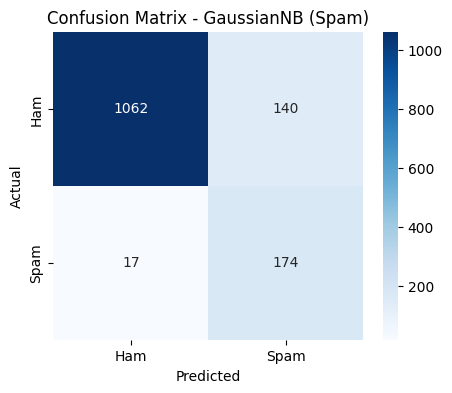

In [7]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

acc_gnb = accuracy_score(y_test, y_pred_gnb)
print("Gaussian Naive Bayes Accuracy:", acc_gnb)
print("\nClassification Report (Gaussian NB):\n", classification_report(y_test, y_pred_gnb))

cm_gnb = confusion_matrix(y_test, y_pred_gnb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_gnb, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - GaussianNB (Spam)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('visuals/confusion_matrix_gaussian.png')
plt.show()

### Bernoulli Naive Bayes


Bernoulli Naive Bayes Accuracy: 0.9698492462311558

Classification Report (Bernoulli NB):
               precision    recall  f1-score   support

           0       0.97      1.00      0.98      1202
           1       0.97      0.81      0.88       191

    accuracy                           0.97      1393
   macro avg       0.97      0.90      0.93      1393
weighted avg       0.97      0.97      0.97      1393



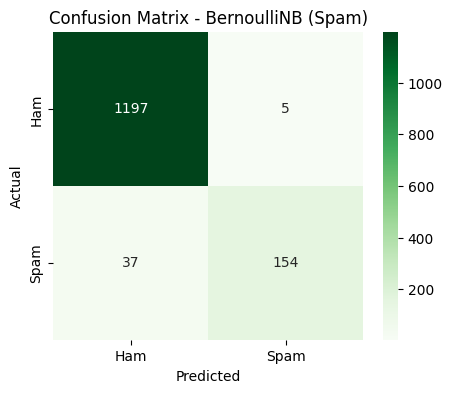

In [8]:
bnb = BernoulliNB()
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

acc_bnb = accuracy_score(y_test, y_pred_bnb)
print("\nBernoulli Naive Bayes Accuracy:", acc_bnb)
print("\nClassification Report (Bernoulli NB):\n", classification_report(y_test, y_pred_bnb))

cm_bnb = confusion_matrix(y_test, y_pred_bnb)
plt.figure(figsize=(5,4))
sns.heatmap(cm_bnb, annot=True, fmt='d', cmap='Greens', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - BernoulliNB (Spam)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('visuals/confusion_matrix_bernoulli.png')
plt.show()

### Accuracy Comparison

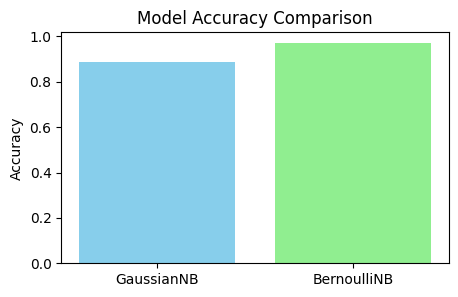

In [9]:
models = ['GaussianNB', 'BernoulliNB']
accuracies = [acc_gnb, acc_bnb]

plt.figure(figsize=(5,3))
plt.bar(models, accuracies, color=['skyblue', 'lightgreen'])
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.savefig('visuals/accuracy_comparison.png')
plt.show()